# Milestone 2 – Data Cleaning & Preprocessing  
## Smart Energy Consumption Analysis and Prediction using Machine Learning  

**Intern Name:** Kunal Bhardwaj  
**GitHub Branch:** kunal_branch  
**Dataset:** Individual Household Electric Power Consumption  

### Objective
The objective of this milestone is to transform raw energy consumption data into a
clean, structured, and model-ready format.

This milestone focuses on:
- Handling missing values using time-series-appropriate techniques
- Detecting and treating outliers
- Resampling data to meaningful time intervals
- Scaling features for machine learning models
- Performing a time-based train–test split

No feature engineering or predictive modeling is performed in this milestone.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


## Loading the Dataset

The dataset is loaded from the local `data/` directory.
The Date and Time columns are combined into a single DateTime index,
which is required for time-series analysis.


In [2]:
file_path = "../data/household_power_consumption.txt"

df = pd.read_csv(
    file_path,
    sep=';',
    parse_dates=[[0, 1]],
    infer_datetime_format=True,
    na_values='?'
)

df.rename(columns={'Date_Time': 'Datetime'}, inplace=True)
df.set_index('Datetime', inplace=True)

print("Dataset Shape:", df.shape)
df.head()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25148\574264264.py:3: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25148\574264264.py:3: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25148\574264264.py:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


Dataset Shape: (2075259, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Missing Value Analysis

Time-series datasets often contain missing sensor readings.
Before applying any cleaning method, it is important to understand
how many values are missing and in which columns.


In [3]:
missing_counts = df.isna().sum()

missing_table = pd.DataFrame({
    "Column": missing_counts.index,
    "Missing Values": missing_counts.values
})

missing_table


,Column,Missing Values
0,Global_active_power,25979
1,Global_reactive_power,25979
2,Voltage,25979
3,Global_intensity,25979
4,Sub_metering_1,25979
5,Sub_metering_2,25979
6,Sub_metering_3,25979


## Missing Value Handling Strategy

Since energy consumption follows temporal continuity:
- Forward fill (`ffill`) is appropriate
- It preserves realistic consumption patterns
- No rows are dropped to avoid breaking time continuity


In [4]:
df_clean = df.fillna(method='ffill')

print("Missing values after cleaning:")
df_clean.isna().sum()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25148\35882786.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean = df.fillna(method='ffill')


Missing values after cleaning:


Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

## Outlier Detection

Extreme spikes in power consumption may be caused by:
- Sensor errors
- Rare abnormal events

We visualize distributions to detect such anomalies.


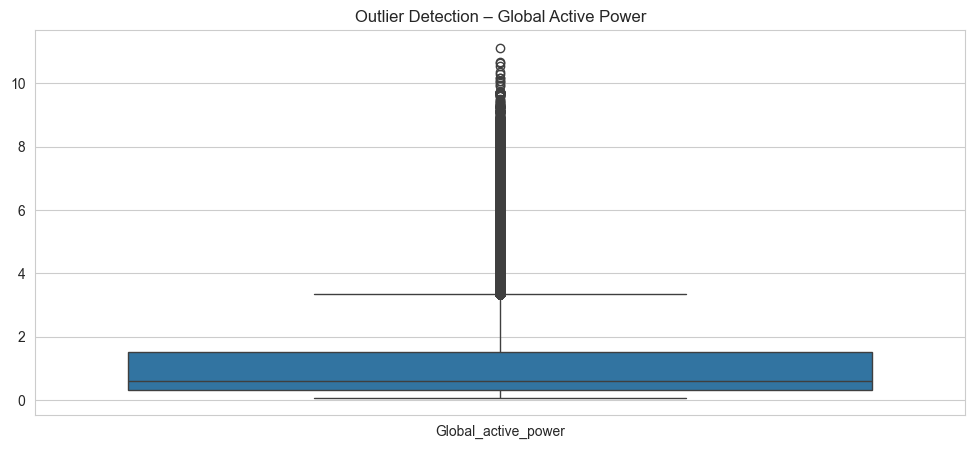

In [5]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_clean[['Global_active_power']])
plt.title("Outlier Detection – Global Active Power")
plt.show()


## Outlier Treatment

Instead of removing outliers, we cap extreme values using
the 99th percentile to preserve overall trends.


In [6]:
upper_limit = df_clean['Global_active_power'].quantile(0.99)

df_clean['Global_active_power'] = np.where(
    df_clean['Global_active_power'] > upper_limit,
    upper_limit,
    df_clean['Global_active_power']
)


## Time Resampling

Minute-level data is resampled to hourly averages to:
- Reduce noise
- Improve model stability
- Align with practical forecasting needs


In [7]:
df_hourly = df_clean.resample('H').mean()

print("Hourly dataset shape:", df_hourly.shape)
df_hourly.head()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25148\3915618578.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_clean.resample('H').mean()


Hourly dataset shape: (34589, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,3.960500,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.504733,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


## Hourly Energy Consumption Trend

This plot validates the resampling process and highlights
long-term consumption patterns.


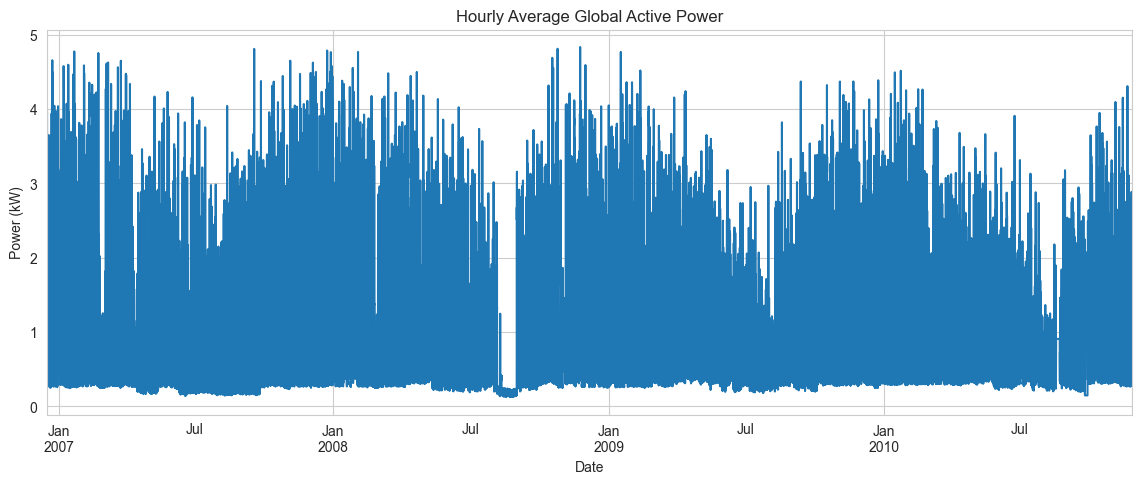

In [8]:
plt.figure(figsize=(14, 5))
df_hourly['Global_active_power'].plot()
plt.title("Hourly Average Global Active Power")
plt.xlabel("Date")
plt.ylabel("Power (kW)")
plt.show()


## Train–Test Split (Time-Based)

Shuffling is NOT used because this is time-series data.
The dataset is split chronologically to avoid data leakage.


In [9]:
split_ratio = 0.8
split_index = int(len(df_hourly) * split_ratio)

train = df_hourly.iloc[:split_index]
test = df_hourly.iloc[split_index:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (27671, 7)
Test shape: (6918, 7)


## Feature Scaling

Scaling is required for:
- Linear regression
- Distance-based models
- Neural networks (LSTM)

StandardScaler is used to normalize feature distributions.


In [10]:
features = train.columns

scaler = StandardScaler()

train_scaled = pd.DataFrame(
    scaler.fit_transform(train),
    index=train.index,
    columns=features
)

test_scaled = pd.DataFrame(
    scaler.transform(test),
    index=test.index,
    columns=features
)

train_scaled.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,3.175935,1.586492,-1.953238,3.439480,-0.321007,-0.189783,1.425021
2006-12-16 18:00:00,2.669872,-0.626005,-1.973665,2.797425,-0.321007,1.236264,1.425775
2006-12-16 19:00:00,2.553840,-0.548773,-2.405665,2.515777,-0.321007,0.018875,1.400886
2006-12-16 20:00:00,2.407644,-0.699277,-2.136720,2.365108,-0.321007,-0.311394,1.414462
2006-12-16 21:00:00,2.172138,-0.676008,-1.147115,2.141673,-0.321007,-0.215386,1.473291


## Final Dataset Summary

The dataset is now clean, consistent, and ready for feature engineering.


In [11]:
summary_table = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Rows": [train_scaled.shape[0], test_scaled.shape[0]],
    "Features": [train_scaled.shape[1], test_scaled.shape[1]]
})

summary_table


,Dataset,Rows,Features
0,Train,27671,7
1,Test,6918,7


## Milestone 2 Conclusion

✔ Missing values handled using forward fill  
✔ Outliers capped using percentile-based approach  
✔ Data resampled to hourly frequency  
✔ Time-based train–test split applied  
✔ Features scaled for ML compatibility  

The dataset is now fully prepared for **Milestone 3 – Feature Engineering**.
